In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

np.random.seed(42)

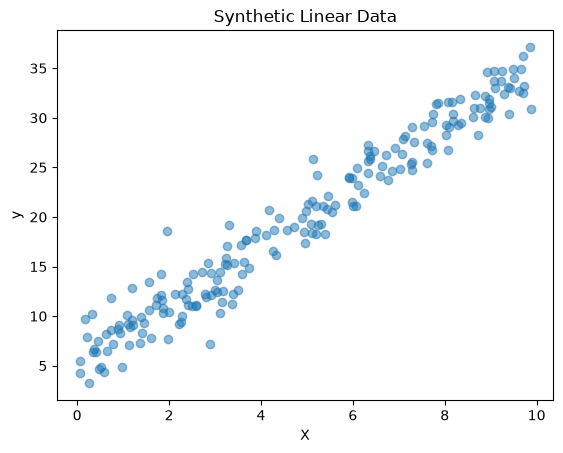

In [2]:
# Generate synthetic linear data: y = 3x + 5 + noise
n_samples = 200
X = np.random.rand(n_samples, 1) * 10
true_w, true_b = 3, 5
y = true_w * X.flatten() + true_b + np.random.randn(n_samples) * 2

plt.scatter(X, y, alpha=0.5)
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Data')
plt.show()

## The Math

Model: y_pred = w*x + b

Loss (MSE): L = (1/n) * sum((y_pred - y)^2)

**Gradients (derived by hand):**

dL/dw = (2/n) * sum((y_pred - y) * x)
dL/db = (2/n) * sum(y_pred - y)

**Update rule:**

w = w - learning_rate * dL/dw
b = b - learning_rate * dL/db

In [3]:
def forward_pass(X, w, b):
    return w * X.flatten() + b


def compute_loss(y_pred, y_true):
    return np.mean((y_pred - y_true) ** 2)


def compute_gradients(X, y_pred, y_true):
    n = len(y_true)
    error = y_pred - y_true
    dw = (2 / n) * np.sum(error * X.flatten())
    db = (2 / n) * np.sum(error)
    return dw, db


def train_batch_gd(X, y, learning_rate=0.01, n_iterations=1000):
    w, b = 0.0, 0.0
    loss_history = []
    
    for i in range(n_iterations):
        y_pred = forward_pass(X, w, b)
        loss = compute_loss(y_pred, y)
        loss_history.append(loss)
        
        dw, db = compute_gradients(X, y_pred, y)
        w -= learning_rate * dw
        b -= learning_rate * db
    
    return w, b, loss_history


w_learned, b_learned, loss_history = train_batch_gd(X, y, learning_rate=0.01, n_iterations=1000)
print(f"Learned w: {w_learned:.4f}, Learned b: {b_learned:.4f}")
print(f"True w: {true_w}, True b: {true_b}")

Learned w: 2.9880, Learned b: 5.1869
True w: 3, True b: 5


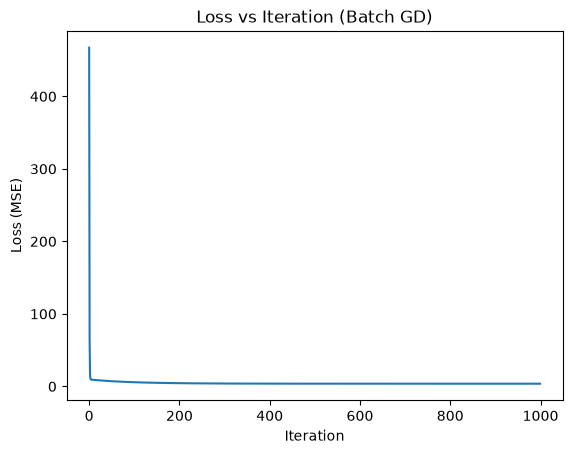

In [4]:
plt.plot(loss_history)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Iteration (Batch GD)')
plt.show()

C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\numpy\_core\_methods.py:132: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
C:\Users\asss\AppData\Local\Temp\ipykernel_16992\921234386.py:6: RuntimeWarning: overflow encountered in square
  return np.mean((y_pred - y_true) ** 2)
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\numpy\_core\fromnumeric.py:83: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\asss\AppData\Local\Temp\ipykernel_16992\921234386.py:27: RuntimeWarning: invalid value encountered in scalar subtract
  w -= learning_rate * dw
C:\Users\asss\Desktop\ai-internship\venv\Lib\site-packages\matplotlib\scale.py:375: RuntimeWarning: overflow encountered in exp
  return np.exp(values * np.log(self.base))


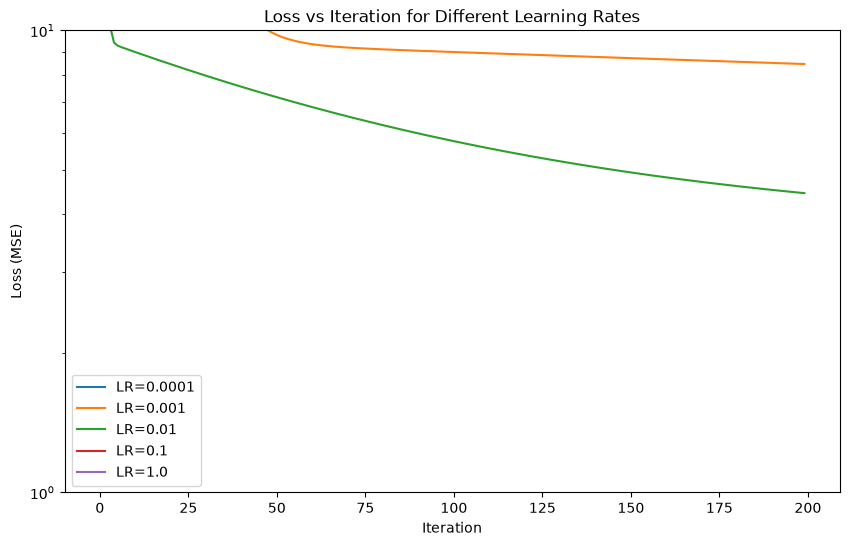

In [5]:
learning_rates = [0.0001, 0.001, 0.01, 0.1, 1.0]

plt.figure(figsize=(10, 6))
for lr in learning_rates:
    _, _, history = train_batch_gd(X, y, learning_rate=lr, n_iterations=200)
    plt.plot(history, label=f'LR={lr}')

plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss vs Iteration for Different Learning Rates')
plt.legend()
plt.yscale('log')
plt.show()

## Learning Rate Analysis

- **LR = 0.0001**: Loss decreases very slowly — too small a step 
  size means the model "crawls" toward the minimum and hasn't 
  converged even after many iterations.
- **LR = 0.001**: Still slow, but noticeably faster than 0.0001.
- **LR = 0.01**: Converges smoothly and reasonably fast — this 
  looks like a good learning rate for this problem.
- **LR = 0.1**: Converges very fast, possibly with some 
  oscillation before settling.
- **LR = 1.0**: Diverges — the loss explodes instead of decreasing, 
  because each step overshoots the minimum by a large margin and 
  the error compounds.

In [6]:
# Closed-form normal equation: w = (X^T X)^-1 X^T y
X_with_bias = np.column_stack([np.ones(len(X)), X.flatten()])
theta_closed_form = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ y
b_closed, w_closed = theta_closed_form

print(f"Closed-form solution: w={w_closed:.4f}, b={b_closed:.4f}")

# sklearn comparison
sklearn_model = LinearRegression()
sklearn_model.fit(X, y)
print(f"sklearn solution: w={sklearn_model.coef_[0]:.4f}, b={sklearn_model.intercept_:.4f}")

print(f"\nMy gradient descent: w={w_learned:.4f}, b={b_learned:.4f}")

Closed-form solution: w=2.9844, b=5.2104
sklearn solution: w=2.9844, b=5.2104

My gradient descent: w=2.9880, b=5.1869


In [1]:
def train_minibatch_sgd(X, y, learning_rate=0.01, n_iterations=1000, batch_size=32):
    w, b = 0.0, 0.0
    loss_history = []
    n = len(y)
    
    for i in range(n_iterations):
        indices = np.random.choice(n, batch_size, replace=False)
        X_batch = X[indices]
        y_batch = y[indices]
        
        y_pred = forward_pass(X_batch, w, b)
        loss = compute_loss(y_pred, y_batch)
        loss_history.append(loss)
        
        dw, db = compute_gradients(X_batch, y_pred, y_batch)
        w -= learning_rate * dw
        b -= learning_rate * db
    
    return w, b, loss_history


w_sgd, b_sgd, sgd_loss_history = train_minibatch_sgd(X, y, learning_rate=0.01, n_iterations=1000, batch_size=32)
print(f"Mini-batch SGD: w={w_sgd:.4f}, b={b_sgd:.4f}")

NameError: name 'X' is not defined